# MPA-MLF Final Project — Room Occupancy Classification
**Author:** Rafael Estévez Marrero and Miguel Martín de las Heras   
**Task:** Classify number of persons (0, 1, 2, 3) in a room from 60 GHz delay-Doppler snapshots  
**Dataset:** PNG images (delay-Doppler domain)  

---
## 0. Setup & Drive Mount

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os


BASE_DIR = '/content/drive/MyDrive/MPA_MLF_Final'

TRAIN_DIR   = f'{BASE_DIR}/x_train'
TEST_DIR    = f'{BASE_DIR}/x_test'
Y_TRAIN_CSV = f'{BASE_DIR}/y_train_v2.csv'
SUBM_CSV    = f'{BASE_DIR}/y_test_submission_example_v2.csv'

print("Checking folders...")
if os.path.exists(TRAIN_DIR):
    train_files = sorted(os.listdir(TRAIN_DIR))
    print(f'Train images found: {len(train_files)}')
else:
    print(f'Train folder not found: {TRAIN_DIR}')

if os.path.exists(TEST_DIR):
    test_files = sorted(os.listdir(TEST_DIR))
    print(f'Test images found: {len(test_files)}')
else:
    print(f'Test folder not found: {TEST_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking folders...
Train images found: 9227
Test images found: 3955


## 1. Imports & Reproducibility

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
import time
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## 2. Exploratory Data Analysis

Total training samples: 9227

Class distribution:
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64


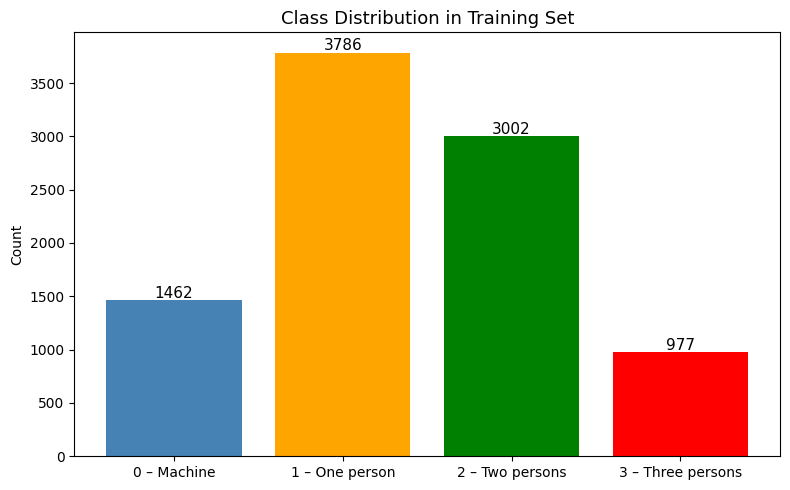

In [ ]:
y_train_df = pd.read_csv(Y_TRAIN_CSV)
print(f'Total training samples: {len(y_train_df)}\n')
print('Class distribution:')
print(y_train_df['target'].value_counts().sort_index())

# Plot class distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = y_train_df['target'].value_counts().sort_index()
ax.bar(['0 – Machine', '1 – One person', '2 – Two persons', '3 – Three persons'],
       counts.values, color=['steelblue','orange','green','red'])
ax.set_title('Class Distribution in Training Set', fontsize=13)
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Dataset & Data Augmentation

In [ ]:
IMG_SIZE = 64

train_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class DelayDopplerDataset(Dataset):
    def __init__(self, img_dir, labels_df=None, transform=None, is_test=False):
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

        if not is_test:
            self.ids = labels_df['id'].values
            self.labels = labels_df['target'].values
        else:
            self.fnames = sorted(os.listdir(img_dir))
            # Extract ID from 'img_X.png'
            self.img_ids = [int(f.replace('.png', '').replace('img_', '').strip()) for f in self.fnames]

    def __len__(self):
        return len(self.fnames) if self.is_test else len(self.ids)

    def __getitem__(self, idx):
        if not self.is_test:
            file_id = int(self.ids[idx])
            img_name = f'img_{file_id + 1}.png'
            label = int(self.labels[idx])
        else:
            img_name = self.fnames[idx]
            label = -1

        img_path = os.path.join(self.img_dir, img_name)
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

# Train / Validation split (80/20 stratified)
train_df, val_df = train_test_split(
    y_train_df, test_size=0.2, random_state=SEED, stratify=y_train_df['target']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# Create dataloaders
BATCH_SIZE = 64
train_dataset = DelayDopplerDataset(TRAIN_DIR, train_df, transform=train_transforms)
val_dataset   = DelayDopplerDataset(TRAIN_DIR, val_df, transform=val_transforms)
test_dataset  = DelayDopplerDataset(TEST_DIR, transform=val_transforms, is_test=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')

Batches — train: 116, val: 29, test: 62


## 4. Model — EfficientNet-B0 (Transfer Learning)

In [ ]:
def build_model(num_classes=4):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model(num_classes=4).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 4,337,024


## 5. Training Setup

In [ ]:
# Handle Class Imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0,1,2,3]), y=train_df['target'].values)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights applied:', class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 40
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Class weights applied: [1.57848589 0.60919445 0.76853394 2.35965473]


## 6. Training Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, desc="Training", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in tqdm(loader, desc="Evaluating", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

## 7. Training Curves

In [ ]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
CKPT_PATH = '/content/best_model.pth'

print(f"Starting training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CKPT_PATH)
        star = 'Model Saved'
    else:
        star = ''

    epoch_time = time.time() - start_time
    print(f'Epoch [{epoch:02d}/{EPOCHS}] | Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} ({epoch_time:.1f}s){star}')

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Starting training for 40 epochs...



Training:   0%|          | 0/116 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [01/40] | Train Acc: 0.5705 | Val Acc: 0.6446 (121.5s)Model Saved


Training:   0%|          | 0/116 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [39/40] | Train Acc: 0.9695 | Val Acc: 0.9464 (46.4s)


Training:   0%|          | 0/116 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch [40/40] | Train Acc: 0.9691 | Val Acc: 0.9518 (46.7s)

Best validation accuracy: 0.9534


## 8. Evaluation on Validation Set

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]


Validation Accuracy: 0.9534
Macro F1-score: 0.9500

Classification Report:
              precision    recall  f1-score   support

  0  Machine       1.00      1.00      1.00       293
   1  person       0.95      0.96      0.96       757
  2  persons       0.97      0.92      0.94       601
  3  persons       0.85      0.96      0.90       195

    accuracy                           0.95      1846
   macro avg       0.94      0.96      0.95      1846
weighted avg       0.96      0.95      0.95      1846



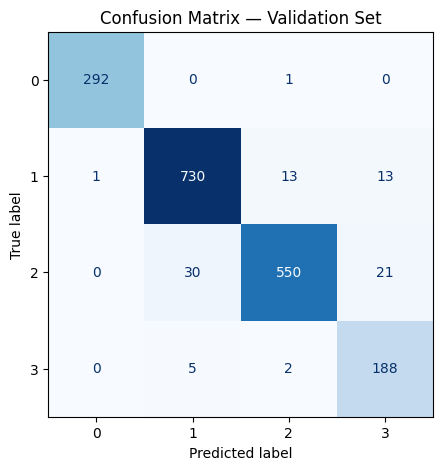

In [ ]:
# Load the best model weights before evaluating
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

_, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)

print(f'\nValidation Accuracy: {val_acc:.4f}')
print(f'Macro F1-score: {f1_score(val_labels, val_preds, average="macro"):.4f}')

print('\nClassification Report:')
CLASS_NAMES = ['0  Machine', '1  person', '2  persons', '3  persons']
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1','2','3'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Validation Set')
plt.show()

## 9. Fine-Tuning Run (optional second stage)

If accuracy is not satisfying, run this cell to do a second fine-tuning pass with a lower learning rate and all layers unfrozen.

In [ ]:
# Load the best weights from Phase 1
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

# Unfreeze all layers for fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Use a much lower learning rate for fine-tuning
optimizer_ft = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler_ft = optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=5, eta_min=1e-6)

FT_EPOCHS = 5
print("Starting Fine-Tuning phase...\n")

for epoch in range(1, FT_EPOCHS + 1):
    start_time = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_ft, criterion, DEVICE)
    va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler_ft.step()

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save(model.state_dict(), CKPT_PATH)
        star = 'Best Model Updated'
    else:
        star = ''

    epoch_time = time.time() - start_time
    print(f'FT Epoch [{epoch:02d}/{FT_EPOCHS}] | Train Acc: {tr_acc:.4f} | Val Acc: {va_acc:.4f} ({epoch_time:.1f}s){star}')

Starting Fine-Tuning phase...



Training:   0%|          | 0/116 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

FT Epoch [01/5] | Train Acc: 0.9663 | Val Acc: 0.9556 (46.9s)Best Model Updated


Training:   0%|          | 0/116 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

FT Epoch [04/5] | Train Acc: 0.9683 | Val Acc: 0.9556 (46.1s)


Training:   0%|          | 0/116 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

FT Epoch [05/5] | Train Acc: 0.9710 | Val Acc: 0.9550 (47.1s)


## 10. Test Set Predictions & Kaggle Submission

In [ ]:
# Ensure we use the absolute best model
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc='Predicting Kaggle Test Set'):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())

# The PDF specifies: input images are numbered from 1, labels from 0.
# Our test_img_ids handles this logic natively.
test_label_ids = [x - 1 for x in test_dataset.img_ids]

submission_df = pd.DataFrame({'id': test_label_ids, 'target': all_preds})
submission_df = submission_df.sort_values('id').reset_index(drop=True)

print(f'\nPrediction distribution on Test Set:')
print(submission_df['target'].value_counts().sort_index())

SUBMISSION_PATH = '/content/kaggle_submission.csv'
submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f'\nSaved to: {SUBMISSION_PATH}')

# Download file to your local computer
from google.colab import files
files.download(SUBMISSION_PATH)

Predicting Kaggle Test Set:   0%|          | 0/62 [00:00<?, ?it/s]


Prediction distribution on Test Set:
target
0     596
1    1641
2    1259
3     459
Name: count, dtype: int64

Saved to: /content/kaggle_submission.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>